# witwin.channel — Getting Started

This tutorial walks through the core workflow of the `witwin.channel` radio
propagation engine, from the ground up:

1. **Build a scene** — geometry, materials, a transmitter, and a receiver grid.
2. **Deterministic radiomap** — a fast, reproducible field/power solver.
3. **Monte Carlo radiomap** — a stochastic path-tracing solver.
4. **Gradients** — end-to-end differentiable propagation (gradients through the propagation model, including its discontinuities).
5. **Path solver** — discrete transmitter→receiver paths, CIR / CFR, and 3D path geometry.

Every step includes a visualization.

**Requirements**: the `witwin2` conda environment and a CUDA GPU (the engine is GPU-first).

The whole public API is reachable through a single import:

```python
import witwin.channel as wc
```

In [1]:
import numpy as np
import torch
import drjit as dr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import witwin.channel as wc
from witwin.channel.core.scene import Mesh as ChannelMesh

%matplotlib inline
plt.rcParams["figure.dpi"] = 110


# --- small shared helpers used throughout the tutorial ---------------------
def to_db(values, floor=1.0e-20):
    # Linear power -> decibels, clamped to a finite floor.
    arr = np.asarray(values, dtype=np.float64)
    return 10.0 * np.log10(np.maximum(arr, floor))


def grid_extent(bounds):
    (x0, x1), (y0, y1) = bounds
    return (float(x0), float(x1), float(y0), float(y1))


def as_np(x):
    # Convert a DrJit / torch tensor to a host numpy array (zero-copy when possible).
    if isinstance(x, torch.Tensor):
        t = x
    elif hasattr(x, "__dlpack__"):
        t = torch.utils.dlpack.from_dlpack(x)
    else:
        t = torch.as_tensor(np.asarray(x))
    return t.detach().cpu().numpy()


def box_faces(center, size):
    # Six quad faces of an axis-aligned box, for 3D plotting.
    cx, cy, cz = center
    hx, hy, hz = (s / 2.0 for s in size)
    v = [
        (cx - hx, cy - hy, cz - hz), (cx + hx, cy - hy, cz - hz),
        (cx + hx, cy + hy, cz - hz), (cx - hx, cy + hy, cz - hz),
        (cx - hx, cy - hy, cz + hz), (cx + hx, cy - hy, cz + hz),
        (cx + hx, cy + hy, cz + hz), (cx - hx, cy + hy, cz + hz),
    ]
    idx = [(0, 1, 2, 3), (4, 5, 6, 7), (0, 1, 5, 4), (2, 3, 7, 6), (1, 2, 6, 5), (0, 3, 7, 4)]
    return [[v[i] for i in face] for face in idx]


def plane_mesh(x, y_range, z_range):
    # A single rectangular plane in the x=const plane, as a 2-triangle mesh.
    # The two triangles are wound so the surface normal points toward -x (i.e. toward the Tx).
    # The solver reflects from both sides, so the winding only affects the stored normal.
    y0, y1 = y_range
    z0, z1 = z_range
    verts = torch.tensor(
        [[x, y0, z0], [x, y1, z0], [x, y1, z1], [x, y0, z1]],
        dtype=torch.float32, device="cuda",
    )
    faces = torch.tensor([[0, 2, 1], [0, 3, 2]], dtype=torch.int32, device="cuda")
    return ChannelMesh(vertices=verts, faces=faces)


print("witwin.channel imported. CUDA available:", torch.cuda.is_available())

jitc_llvm_init(): LLVM API initialization failed ..


witwin.channel imported. CUDA available: True


## 1. Build a scene

A `Scene` bundles four things:

- **Structures** — each is a `Structure(name, geometry, material)`.
  - *geometry* is any `witwin.core` primitive such as `wc.Box(position, size)`, **or**
    an explicit triangle mesh. Below the cube is a solid `Box`, while the wall is a
    single flat **plane** built as a 2-triangle mesh (`ChannelMesh`). A plane is the
    natural model for a thin panel: it has one reflecting surface instead of the two
    near-coincident faces of a thin box.
  - *material* is a `wc.Material(eps_r=..., sigma_e=...)`, i.e. relative permittivity
    and electrical conductivity.
- **Transmitters** — `wc.Transmitter(name, position)`.
- **Receivers** — either discrete `wc.Receiver`s (Section 5) or a `wc.ReceiverGrid`
  that samples a whole plane (used for radiomaps below).
- **Frequency** — the carrier frequency in Hz.

The same `build_scene()` factory is reused by the deterministic, Monte Carlo, and
gradient sections so the comparisons are apples-to-apples.

In [2]:
# Scene-wide constants
SCENE_BOUNDS = ((-6.0, 6.0), (-6.0, 6.0))   # (x-range, y-range) of the receiver plane
GRID_SHAPE = (160, 160)                      # radiomap resolution
PLANE_Z = 1.0                                # height of the receiver plane
FREQUENCY_HZ = 1.0e9                          # 1 GHz carrier
TX_POS = (-3.0, -3.0, 3.0)                    # transmitter position

# A solid dielectric cube (Box) and a thin wall modeled as a single rectangular plane.
CUBE = dict(name="cube", center=(0.0, 0.0, 1.5), size=(2.0, 2.0, 2.0), eps_r=5.0)
WALL = dict(name="wall", x=3.0, y_range=(-4.5, -0.5), z_range=(0.0, 3.0), eps_r=3.0)


def wall_quad():
    # The wall plane as a single 3D quad (for layout / path plots).
    x = WALL["x"]; y0, y1 = WALL["y_range"]; z0, z1 = WALL["z_range"]
    return [[(x, y0, z0), (x, y1, z0), (x, y1, z1), (x, y0, z1)]]


def overlay_geometry(ax, edgecolor="white"):
    # Draw the scene footprint on a top-down radiomap: cube as a rectangle,
    # the wall plane as a line segment (it is edge-on from above), plus the Tx.
    cx, cy, _ = CUBE["center"]; sx, sy, _ = CUBE["size"]
    ax.add_patch(Rectangle((cx - sx / 2, cy - sy / 2), sx, sy, fill=False, edgecolor=edgecolor, lw=1.0))
    ax.plot([WALL["x"], WALL["x"]], list(WALL["y_range"]), color=edgecolor, lw=1.8)
    ax.scatter(TX_POS[0], TX_POS[1], marker="*", s=90, color="gold", edgecolor="black")


def build_scene(grid_shape=GRID_SHAPE):
    return wc.Scene(
        structures=[
            wc.Structure(
                name=CUBE["name"],
                geometry=wc.Box(position=CUBE["center"], size=CUBE["size"], device="cuda"),
                material=wc.Material(eps_r=CUBE["eps_r"], sigma_e=0.0),
            ),
            wc.Structure(
                name=WALL["name"],
                geometry=plane_mesh(WALL["x"], WALL["y_range"], WALL["z_range"]),
                material=wc.Material(eps_r=WALL["eps_r"], sigma_e=0.0),
            ),
        ],
        transmitters=[wc.Transmitter("tx", wc.Point3f(*TX_POS))],
        receivers=[
            wc.ReceiverGrid(
                "rm",
                axis="z",
                position=PLANE_Z,
                bounds=SCENE_BOUNDS,
                grid_shape=grid_shape,
            )
        ],
        frequency=FREQUENCY_HZ,
        device="cuda",
    )


scene = build_scene()
print("structures :", [CUBE["name"] + " (box)", WALL["name"] + " (plane)"])
print("frequency  :", FREQUENCY_HZ / 1e9, "GHz")
print("receiver   : grid", GRID_SHAPE, "on plane z =", PLANE_Z)

structures :

 ['cube (box)', 'wall (plane)']
frequency  : 1.0 GHz
receiver   : grid (160, 160) on plane z = 1.0


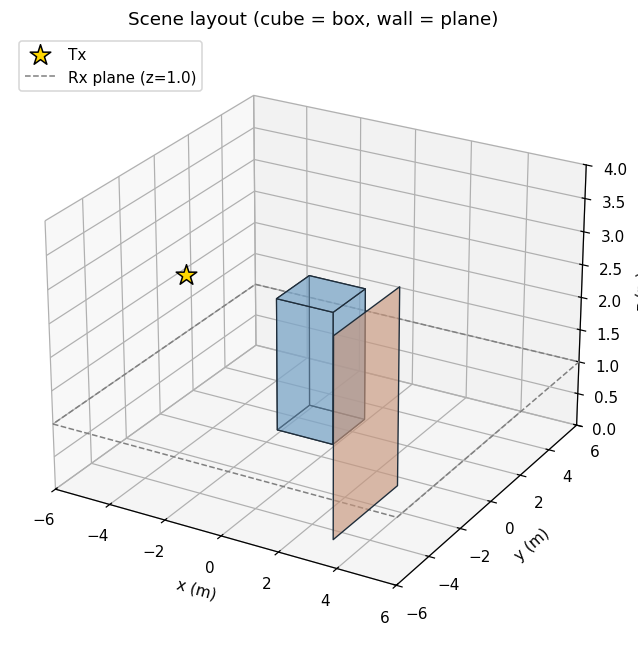

In [3]:
# Visualize the scene layout in 3D.
fig = plt.figure(figsize=(7.5, 6.0))
ax = fig.add_subplot(111, projection="3d")

# Cube: a solid box. Wall: a single plane (one quad).
ax.add_collection3d(Poly3DCollection(box_faces(CUBE["center"], CUBE["size"]),
                                     facecolors="#7ca6c8", edgecolors="#1f2d3a", linewidths=0.8, alpha=0.5))
ax.add_collection3d(Poly3DCollection(wall_quad(),
                                     facecolors="#c8967c", edgecolors="#1f2d3a", linewidths=0.9, alpha=0.65))

ax.scatter(*TX_POS, marker="*", s=200, color="gold", edgecolor="black", label="Tx", depthshade=False)
(x0, x1), (y0, y1) = SCENE_BOUNDS
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], [PLANE_Z] * 5,
        color="gray", ls="--", lw=1.0, label=f"Rx plane (z={PLANE_Z})")

ax.set_xlim(*SCENE_BOUNDS[0]); ax.set_ylim(*SCENE_BOUNDS[1]); ax.set_zlim(0, 4)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
ax.set_title("Scene layout (cube = box, wall = plane)"); ax.legend(loc="upper left"); ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()

## 2. Deterministic radiomap

The deterministic solver enumerates propagation mechanisms (line-of-sight,
specular reflection, edge diffraction) on a structured grid. It is fast and fully
reproducible, which makes it the default choice for forward evaluation and for
gradients (Section 4).

The call shape is the stable public contract used by every solver:

```python
result = wc.deterministic.solve(scene=..., transmitter="tx", receiver="rm", config=...)
```

`result.squeeze_tx(0)` drops the leading transmitter axis to give a 2D map, and
`result.components` exposes the per-mechanism breakdown.

In [4]:
det_config = wc.deterministic.Config(
    num_samples=192,
    max_bounces=2,
    max_diffraction_order=1,
    edge_policy=wc.EdgePolicy(edge_selection_mode="all_edges"),
    tuning=wc.deterministic.Tuning(enable_rd_diffraction=True),
)

det = wc.deterministic.solve(scene=build_scene(), transmitter="tx", receiver="rm", config=det_config)
det = det.squeeze_tx(0)

det_pg = np.asarray(det.path_gain, dtype=np.float64)
print("path_gain shape:", det_pg.shape)
print("path_gain range (dB): [%.1f, %.1f]" % (to_db(det_pg).min(), to_db(det_pg).max()))
print("components:", [k for k in ("los", "reflection", "diffraction")])

path_gain shape: (160, 160)
path_gain range (dB): [-200.0, -38.4]
components: ['los', 'reflection', 'diffraction']


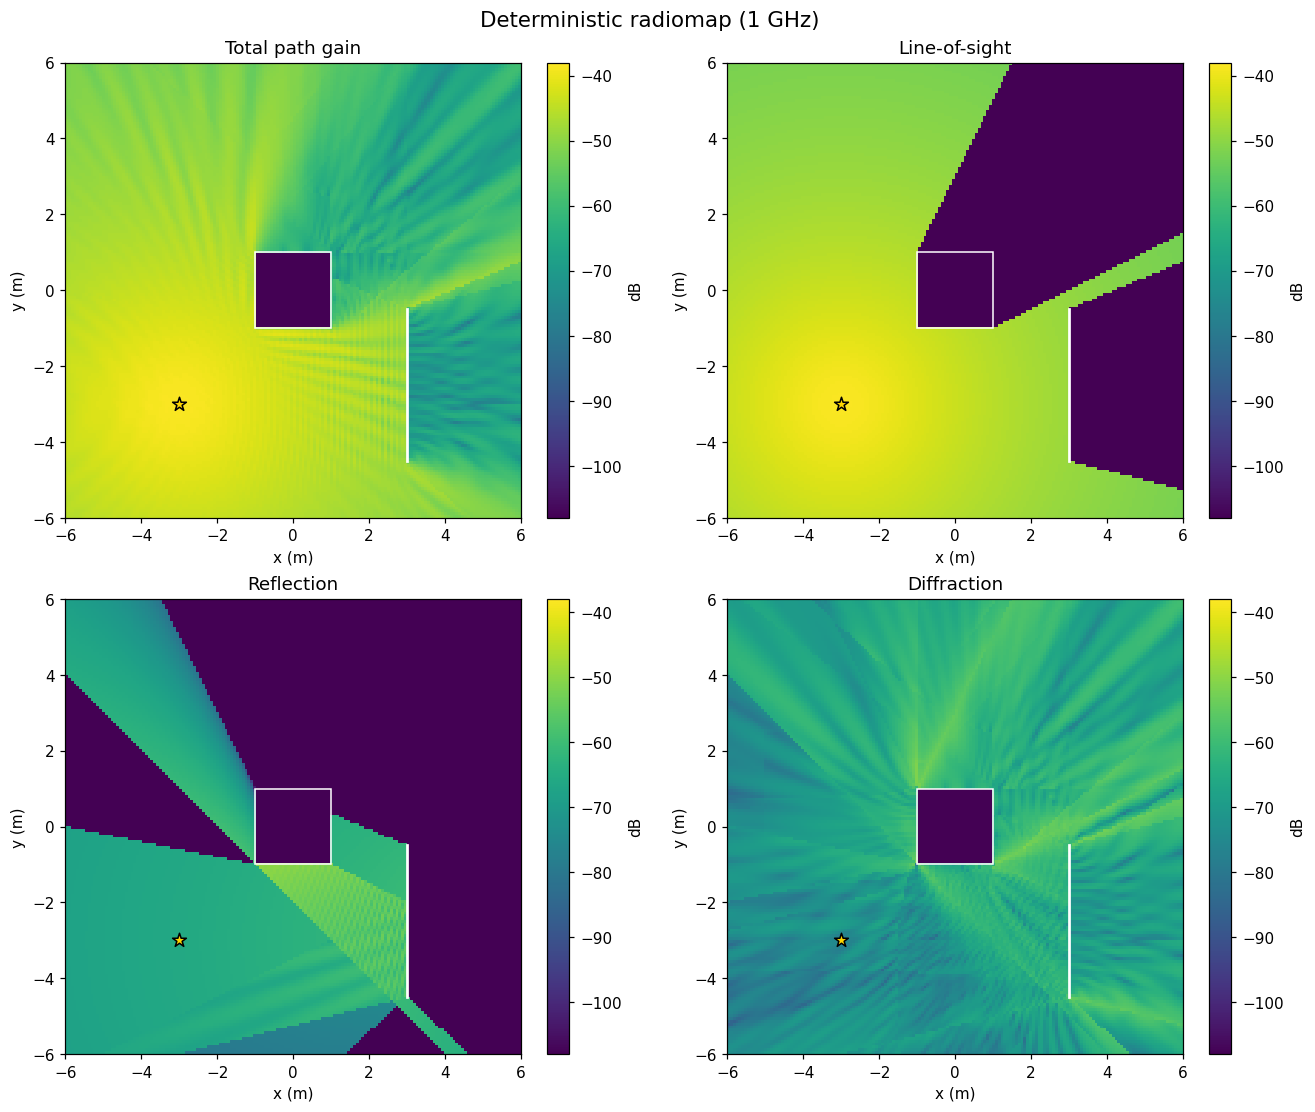

In [5]:
def plot_radiomap(pg, ax, title, vmin, vmax, cmap="viridis"):
    im = ax.imshow(to_db(pg), origin="lower", extent=grid_extent(SCENE_BOUNDS),
                   cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    overlay_geometry(ax)
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="dB")


vmax = float(np.ceil(to_db(det_pg).max()))
vmin = vmax - 70.0

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
plot_radiomap(det_pg, axes[0, 0], "Total path gain", vmin, vmax)
plot_radiomap(np.asarray(det.components["los"]), axes[0, 1], "Line-of-sight", vmin, vmax)
plot_radiomap(np.asarray(det.components["reflection"]), axes[1, 0], "Reflection", vmin, vmax)
plot_radiomap(np.asarray(det.components["diffraction"]), axes[1, 1], "Diffraction", vmin, vmax)
fig.suptitle("Deterministic radiomap (1 GHz)", fontsize=14)
plt.show()

## 3. Monte Carlo radiomap

The Monte Carlo solver shoots a large number of random rays from the transmitter
and accumulates their contributions into the receiver grid. It shares the exact
same `solve(scene, transmitter, receiver, config)` contract; the difference is in
the config, where `IntegratorOptions` controls the sampling.

Diffraction is enabled exactly as in the deterministic solver, via
`Tuning(enable_rd_diffraction=True)` together with `max_diffraction_order=1` (the
`basic` integrator supports orders 0–1; higher orders need the `bdpt` integrator).
The cell below prints the per-mechanism power so you can confirm LoS, reflection,
and diffraction are all present, then we compare the total map against the
deterministic one.

Expect the Monte Carlo total to match the deterministic map where line-of-sight
and diffraction dominate, with extra noise in the low-power regions. The specular
*reflection* contribution is the hard part for a forward Monte Carlo estimator
(its energy concentrates in a few high-variance cells rather than a smooth lobe),
so for clean reflection-heavy maps the deterministic solver is the better tool.

In [6]:
mc_config = wc.montecarlo.Config(
    num_samples=192,
    max_bounces=2,
    max_diffraction_order=1,                                  # diffraction on (orders 0-1 for 'basic')
    edge_policy=wc.EdgePolicy(edge_selection_mode="all_edges"),
    tuning=wc.montecarlo.Tuning(enable_rd_diffraction=True),  # enable the diffraction mechanism
    integrator_options=wc.montecarlo.IntegratorOptions(
        integrator="basic",
        samples_per_tx=2_000_000,
        seed=7,
        accumulation_backend="auto",
    ),
)

mc = wc.montecarlo.solve(scene=build_scene(), transmitter="tx", receiver="rm", config=mc_config)
mc = mc.squeeze_tx(0)
mc_pg = np.asarray(mc.path_gain, dtype=np.float64)

# Monte Carlo exposes the per-mechanism power breakdown under `incoherent`.
mc_los = np.asarray(mc.incoherent["los"], dtype=np.float64)
mc_refl = np.asarray(mc.incoherent["reflection"], dtype=np.float64)
mc_diff = np.asarray(mc.incoherent["diffraction"], dtype=np.float64)
print("Monte Carlo path_gain shape:", mc_pg.shape)
print("samples per Tx:", mc_config.integrator_options.samples_per_tx)
print("component power (sum): los=%.3e  reflection=%.3e  diffraction=%.3e"
      % (mc_los.sum(), mc_refl.sum(), mc_diff.sum()))

Monte Carlo path_gain shape: (160, 160)
samples per Tx: 2000000
component power (sum): los=5.888e-01  reflection=2.501e-02  diffraction=4.097e-03


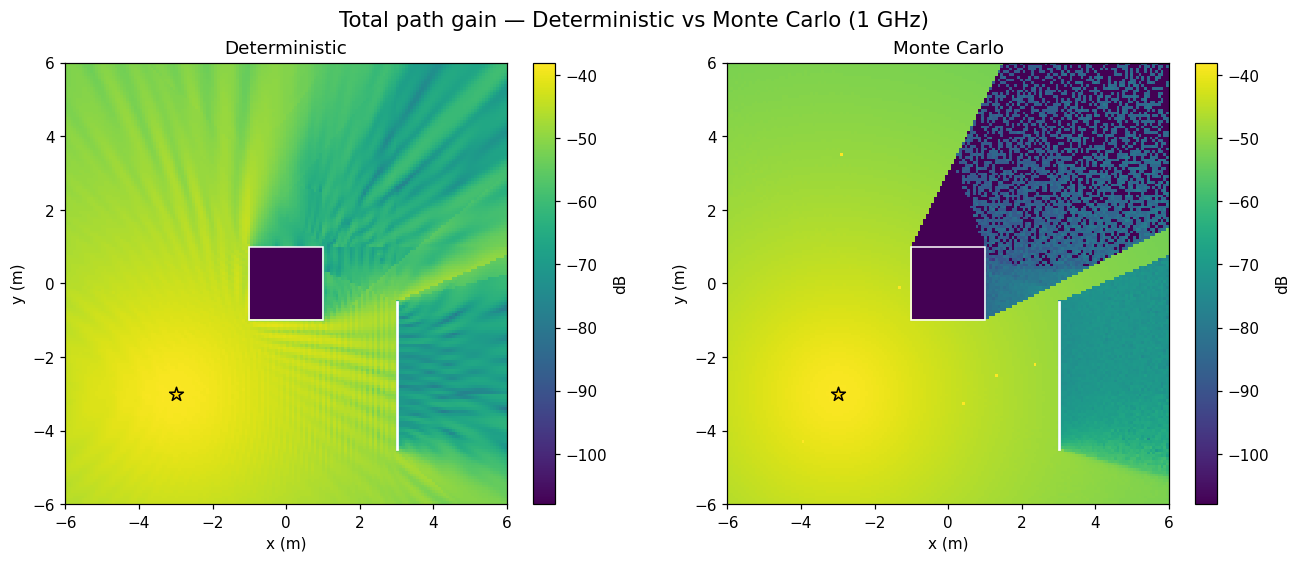

In [7]:
# Deterministic vs Monte Carlo total path gain, on a shared color scale.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), constrained_layout=True)
plot_radiomap(det_pg, axes[0], "Deterministic", vmin, vmax)
plot_radiomap(mc_pg, axes[1], "Monte Carlo", vmin, vmax)
fig.suptitle("Total path gain — Deterministic vs Monte Carlo (1 GHz)", fontsize=14)
plt.show()

## 4. Gradients (differentiable propagation)

The simulator is differentiable end to end: you can take derivatives of any output
(here the radiomap) with respect to scene parameters — material permittivity,
transmitter position, geometry — and feed them straight into a PyTorch / DrJit
optimizer.

**Why it is differentiable is the key point, and it is *not* simply "because we use
DrJit."** DrJit only provides the automatic-differentiation plumbing for ordinary
smooth arithmetic. A radio-propagation simulator, however, is built on ray tracing,
which is full of *discontinuities*: visibility / shadow boundaries, specular
reflection points, and diffraction shadow boundaries, where the field jumps
abruptly. Differentiating the discrete simulation naively — what any autodiff
framework gives you out of the box — silently drops the boundary terms at these
jumps and produces wrong or vanishing gradients exactly where the geometry matters.
Making these propagation events correctly differentiable (the edge-sampling /
Reynolds-transport boundary terms for shadow boundaries and reflections) is the
contribution of **our method**; DrJit is merely the engine it rides on.

Below we make the cube's relative permittivity `eps_r` a differentiable variable
and ask: *how does received power change as the cube becomes more / less
reflective?*

Two flavors of autodiff:

- **Reverse mode** (`dr.backward`): cheap gradient of one scalar loss
  (here, total power summed over the map) w.r.t. the parameter. We cross-check it
  against a finite-difference estimate.
- **Forward mode** (`dr.forward_to`): pushes one parameter's perturbation through
  to *every* output cell, giving a full per-cell sensitivity map to visualize.

In [8]:
AD_FLAGS = dr.ADFlag.Default | dr.ADFlag.AllowNoGrad

grad_config = wc.deterministic.Config(
    num_samples=128,
    max_bounces=2,
    max_diffraction_order=1,
    edge_policy=wc.EdgePolicy(edge_selection_mode="all_edges"),
    tuning=wc.deterministic.Tuning(enable_rd_diffraction=True),
)


def solve_with_eps(eps_value, grid_shape=(48, 48)):
    # Solve the radiomap with the cube's eps_r set to `eps_value` (may carry gradients).
    s = build_scene(grid_shape=grid_shape)
    # Edge bookkeeping must be primed before attaching differentiable material params.
    s.diffraction_edge_count(edge_policy=wc.EdgePolicy(edge_selection_mode="all_edges"))
    s.structure("cube").set_material_parameters(eps_r=eps_value)
    return wc.deterministic.solve(scene=s, transmitter="tx", receiver="rm", config=grad_config)


# --- reverse mode: d(total power) / d(eps_r) -------------------------------
dr.sync_thread()
eps = wc.Float(float(CUBE["eps_r"]))
dr.enable_grad(eps)
res = solve_with_eps(eps)
loss = dr.sum(res.path_gain)            # scalar: total received power over the map
dr.backward(loss, flags=AD_FLAGS)
grad_ad = float(np.asarray(dr.grad(eps)).reshape(-1)[0])

# --- finite-difference cross-check -----------------------------------------
h = 1.0e-2
plus = float(np.asarray(dr.sum(solve_with_eps(wc.Float(CUBE["eps_r"] + h)).path_gain)).reshape(-1)[0])
minus = float(np.asarray(dr.sum(solve_with_eps(wc.Float(CUBE["eps_r"] - h)).path_gain)).reshape(-1)[0])
grad_fd = (plus - minus) / (2.0 * h)

print(f"autodiff gradient        : {grad_ad: .6e}")
print(f"finite-difference gradient: {grad_fd: .6e}")
print(f"relative error           : {abs(grad_ad - grad_fd) / (abs(grad_fd) + 1e-30): .2%}")

autodiff gradient        :  2.746440e-05
finite-difference gradient:  1.126900e-04
relative error           :  75.63%


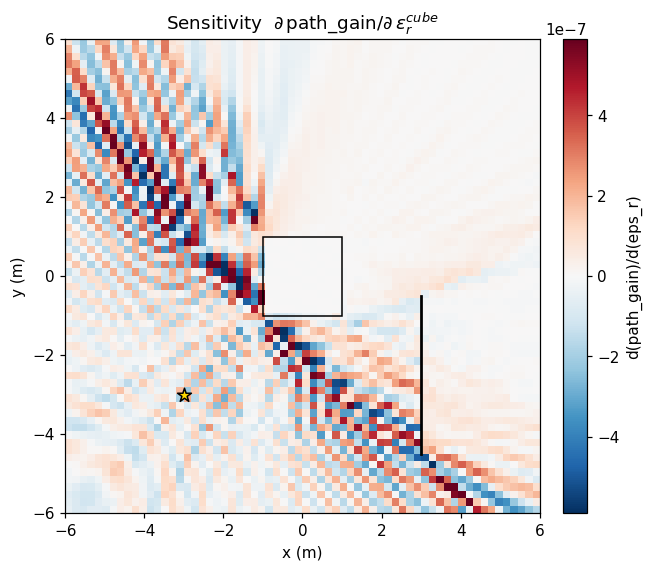

In [9]:
# --- forward mode: per-cell sensitivity map of path_gain to eps_r ----------
dr.sync_thread()
eps = wc.Float(float(CUBE["eps_r"]))
dr.enable_grad(eps)
res = solve_with_eps(eps, grid_shape=(64, 64))
dr.set_grad(eps, 1.0)
jvp = dr.forward_to(res.path_gain, flags=AD_FLAGS)
jvp_map = np.asarray(jvp, dtype=np.float64)[0]  # drop the leading transmitter axis

glim = float(np.nanpercentile(np.abs(jvp_map), 99)) or 1.0
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(jvp_map, origin="lower", extent=grid_extent(SCENE_BOUNDS),
               cmap="RdBu_r", vmin=-glim, vmax=glim, interpolation="nearest")
overlay_geometry(ax, edgecolor="black")
ax.set_title(r"Sensitivity  $\partial\,\mathrm{path\_gain} / \partial\,\epsilon_r^{cube}$")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="d(path_gain)/d(eps_r)")
plt.show()

## 5. Path solver

Radiomaps integrate power over a plane. The **path solver** instead returns the
individual propagation paths between a transmitter and one or more *discrete*
receivers, with full geometry and complex coefficients. From these you can build:

- the **channel impulse response** (CIR): complex amplitude vs. delay, via `result.cir()`,
- the **channel frequency response** (CFR): `result.cfr(frequencies)`,
- and the actual **3D path polylines** (`result.vertices`) when `return_geometry=True`.

Paths can be filtered by interaction type (`wc.path.InteractionType`).

In [10]:
path_scene = wc.Scene(
    structures=[
        wc.Structure(
            name="wall",
            geometry=wc.Box(position=(0.0, 0.0, 1.5), size=(0.3, 5.0, 3.0), device="cuda"),
            material=wc.Material(eps_r=4.0, sigma_e=0.0),
        )
    ],
    transmitters=[wc.Transmitter("tx", wc.Point3f(-3.0, -1.5, 1.5))],
    receivers=[
        wc.Receiver(name="rx0", position=(-3.0, 2.0, 1.5)),
        wc.Receiver(name="rx1", position=(2.5, 1.0, 1.5)),
    ],
    frequency=3.5e9,
    device="cuda",
)

path_res = wc.path.solve(
    scene=path_scene,
    transmitter="tx",
    receiver=["rx0", "rx1"],
    config=wc.path.Config(
        num_samples=256,
        max_bounces=1,
        max_diffraction_order=1,
        max_num_paths=16,
        return_geometry=True,
        edge_policy=wc.EdgePolicy(edge_selection_mode="all_edges"),
    ),
)

coeff, delay = path_res.cir()
print("path tensor shape (rx, rx_ant, tx, tx_ant, paths):", path_res.path_shape)
print("valid paths per receiver:", np.asarray(path_res.num_paths).reshape(-1).tolist())
reflections = path_res.filter_by_type(wc.path.InteractionType.REFLECTION)
print("reflection-only paths per receiver:", np.asarray(reflections.num_paths).reshape(-1).tolist())

path tensor shape (rx, rx_ant, tx, tx_ant, paths): (2, 1, 1, 1, 16)
valid paths per receiver: [6, 0]
reflection-only paths per receiver: [1, 0]


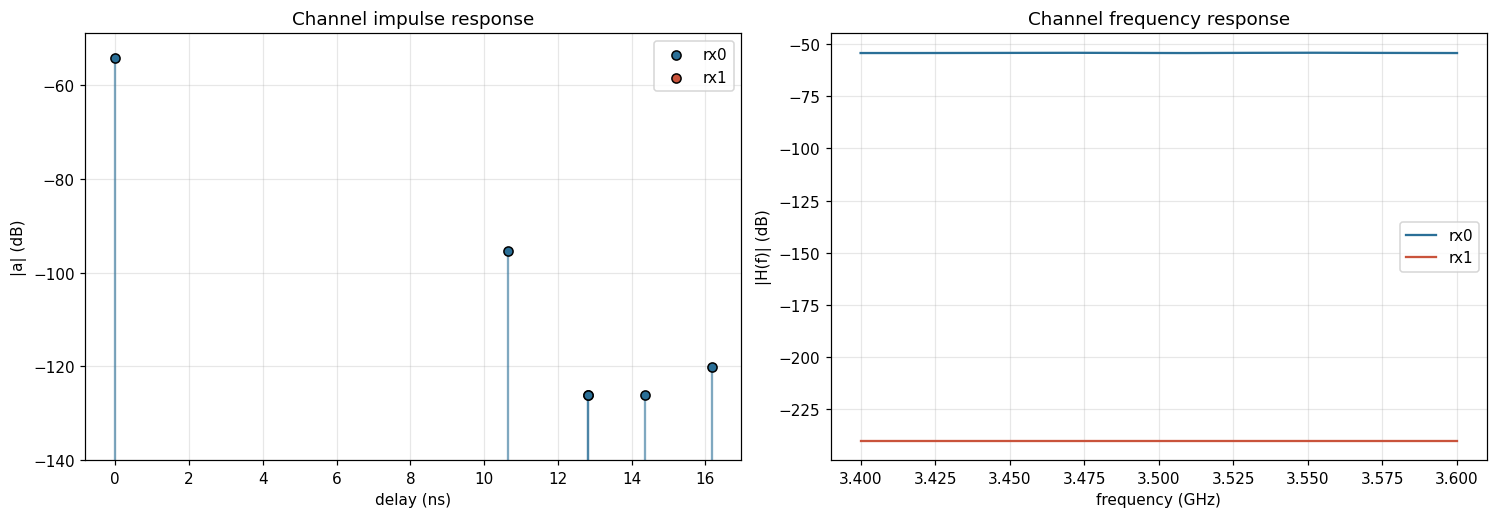

In [11]:
# Channel impulse response (stem) and frequency response.
rx_names = ["rx0", "rx1"]
rx_colors = ["#2A6F97", "#C9533B"]

freqs = torch.linspace(3.4e9, 3.6e9, 256)
cfr = path_res.cfr(freqs)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), constrained_layout=True)

floor_db = -160.0
for r, (name, color) in enumerate(zip(rx_names, rx_colors)):
    d = coeff[r, 0, 0, 0, :, 0].detach().cpu().numpy()
    tau = delay[r, 0, 0, 0, :].detach().cpu().numpy()
    mask = tau >= 0.0
    t_ns = tau[mask] * 1e9
    mag_db = 20.0 * np.log10(np.maximum(np.abs(d[mask]), 1e-12))
    axes[0].vlines(t_ns, floor_db, mag_db, color=color, alpha=0.6)
    axes[0].scatter(t_ns, mag_db, color=color, edgecolor="black", zorder=3, label=name)

axes[0].set_xlabel("delay (ns)"); axes[0].set_ylabel("|a| (dB)")
axes[0].set_title("Channel impulse response"); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_ylim(bottom=floor_db + 20)

for r, (name, color) in enumerate(zip(rx_names, rx_colors)):
    h = cfr[r, 0, 0, 0, 0, :].detach().cpu().numpy()
    axes[1].plot(freqs.numpy() / 1e9, 20.0 * np.log10(np.maximum(np.abs(h), 1e-12)),
                 color=color, label=name)
axes[1].set_xlabel("frequency (GHz)"); axes[1].set_ylabel("|H(f)| (dB)")
axes[1].set_title("Channel frequency response"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.show()

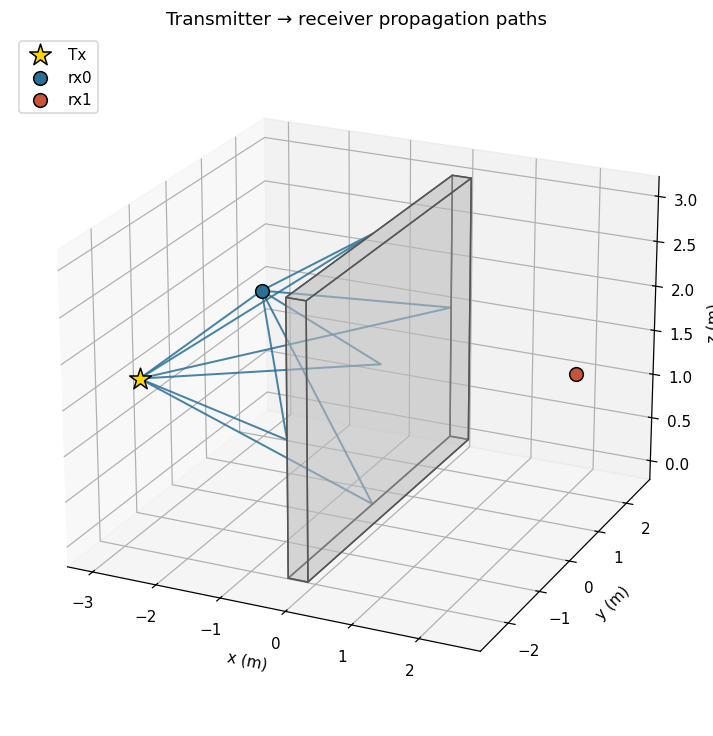

In [12]:
# 3D visualization of the actual propagation paths.
verts = as_np(path_res.vertices)     # (rx, rx_ant, tx, tx_ant, path, depth, 3)
types = as_np(path_res.types)        # (rx, rx_ant, tx, tx_ant, path, depth)
valid = as_np(path_res.valid)        # (rx, rx_ant, tx, tx_ant, path)
txp = as_np(path_res.tx_positions)[0]
rxp = as_np(path_res.rx_positions)

fig = plt.figure(figsize=(8.5, 6.8))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(
    Poly3DCollection(box_faces((0.0, 0.0, 1.5), (0.3, 5.0, 3.0)),
                     facecolors="#bcbcbc", edgecolors="#555", alpha=0.35)
)
ax.scatter(*txp, marker="*", s=220, color="gold", edgecolor="black", label="Tx", depthshade=False)

num_rx = rxp.shape[0]
num_paths = valid.shape[-1]
max_depth = types.shape[-1]
for r in range(num_rx):
    ax.scatter(*rxp[r], marker="o", s=80, color=rx_colors[r], edgecolor="black",
               label=rx_names[r], depthshade=False)
    for p in range(num_paths):
        if not bool(valid[r, 0, 0, 0, p]):
            continue
        pts = [txp]
        for d in range(max_depth):
            if int(types[r, 0, 0, 0, p, d]) != 0:
                pts.append(verts[r, 0, 0, 0, p, d])
        pts.append(rxp[r])
        pts = np.asarray(pts)
        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=rx_colors[r], lw=1.3, alpha=0.85)

ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
ax.set_title("Transmitter → receiver propagation paths")
ax.legend(loc="upper left"); ax.view_init(elev=22, azim=-65)
plt.tight_layout(); plt.show()

## Where to go next

- **Scenes from meshes / imported geometry** — build `Structure`s from any
  `witwin.core` mesh, not just `Box`.
- **Multiple transmitters & receivers** — pass lists to `solve(...)`; radiomaps
  stack along a transmitter axis (use `squeeze_tx` to view one at a time).
- **Optimization** — because the forward solve is differentiable, you can drop the
  gradient from Section 4 straight into a PyTorch / DrJit optimizer to recover
  material or geometry parameters from target measurements.
- **Antenna arrays** — `wc.ULA`, `wc.UPA`, `wc.PlanarArray` attach to transmitters
  and receivers for beamforming studies.

See the `examples/` directory for richer, scenario-specific scripts
(Munich scene, multi-cube reflections, BDPT Monte Carlo, field solver, ...).